# **TinyBayes: Closed-Form Bayesian Inference via Jacobi Prior for Real-Time Image Classification on Edge Devices**

# **Step 1: Mount Google Drive, Set paths, Install libraries**

In [ ]:
# ------------------------------------------------------------------------------
# Google Drive
# ------------------------------------------------------------------------------

from google.colab import drive
drive.mount('/content/drive')

# ------------------------------------------------------------------------------
# OS & File Management
# ------------------------------------------------------------------------------

import os
import shutil
import time
import pickle

# ------------------------------------------------------------------------------
# Data Handling
# ------------------------------------------------------------------------------

import pandas as pd
import numpy as np

# ------------------------------------------------------------------------------
# Computer Vision
# ------------------------------------------------------------------------------

import cv2
from tqdm import tqdm

# ------------------------------------------------------------------------------
# PyTorch
# ------------------------------------------------------------------------------

import torch
import torchvision
from torchvision import transforms
import torchvision.models as models
from torchvision.models import (
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

# ------------------------------------------------------------------------------
# Machine Learning
# ------------------------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

# ------------------------------------------------------------------------------
# Gaussian Process Regression
# ------------------------------------------------------------------------------

from scipy import stats
from numpy.linalg import inv

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel as C
)

# ------------------------------------------------------------------------------
# Visualization
# ------------------------------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# YOLOv8
# ------------------------------------------------------------------------------

!pip install ultralytics -q

from ultralytics import YOLO

# ------------------------------------------------------------------------------
# TinyBayes Dataset Paths
# ------------------------------------------------------------------------------

DATASET_ROOT = "/content/drive/MyDrive/TinyBayes/amini_dataset"

BASE_DIR = os.path.join(DATASET_ROOT, "dataset")

CSV_PATH_TRAIN = os.path.join(DATASET_ROOT, "Train.csv")
CSV_PATH_TEST = os.path.join(DATASET_ROOT, "Test.csv")

IMAGE_DIR_TRAIN = os.path.join(BASE_DIR, "images", "train")
IMAGE_DIR_TEST = os.path.join(BASE_DIR, "images", "test")
IMAGE_DIR_VAL = os.path.join(BASE_DIR, "images", "val")

LABEL_DIR_TRAIN = os.path.join(BASE_DIR, "labels", "train")

# Save ALL generated models/results permanently to Drive
SAVE_DIR = "/content/drive/MyDrive/TinyBayes/run_2000"

# ------------------------------------------------------------------------------
# Create required folders
# ------------------------------------------------------------------------------

os.makedirs(IMAGE_DIR_VAL, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------------------------
# Verify dataset structure
# ------------------------------------------------------------------------------

print("=" * 60)
print("VERIFYING DATASET")
print("=" * 60)

print("Train CSV      :", os.path.exists(CSV_PATH_TRAIN))
print("Test CSV       :", os.path.exists(CSV_PATH_TEST))

print("Train Images   :", os.path.exists(IMAGE_DIR_TRAIN))
print("Test Images    :", os.path.exists(IMAGE_DIR_TEST))
print("Validation Dir :", os.path.exists(IMAGE_DIR_VAL))

print("Train Labels   :", os.path.exists(LABEL_DIR_TRAIN))
print("Output Folder  :", os.path.exists(SAVE_DIR))

# ------------------------------------------------------------------------------
# Load CSV files
# ------------------------------------------------------------------------------

df_train = pd.read_csv(CSV_PATH_TRAIN)
df_test = pd.read_csv(CSV_PATH_TEST)

# ------------------------------------------------------------------------------
# Device Info
# ------------------------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\n" + "=" * 60)
print("SYSTEM INFO")
print("=" * 60)

print(f"Device: {device}")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not Available")

# ------------------------------------------------------------------------------
# Dataset Summary
# ------------------------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(f"Train Samples : {len(df_train)}")
print(f"Test Samples  : {len(df_test)}")

print("\nTrain Columns:")
print(df_train.columns.tolist())

print("\nFirst 5 Training Rows:")
display(df_train.head())

print("\nTrain CSV Shape:")
print(df_train.shape)

print("\nTest CSV Shape:")
print(df_test.shape)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
VERIFYING DATASET
Train CSV      : True
Test CSV       : True
Train Images   : True
Test Images    : True
Validation Dir : True
Train Labels   : True
Output Folder  : True

SYSTEM INFO
Device: cpu
GPU: Not Available

DATASET SUMMARY
Train Samples : 9792
Test Samples  : 1626

Train Columns:
['Image_ID', 'class', 'confidence', 'ymin', 'xmin', 'ymax', 'xmax', 'class_id', 'ImagePath']

First 5 Training Rows:


,Image_ID,class,confidence,ymin,xmin,ymax,xmax,class_id,ImagePath
0,ID_nBgcAR.jpg,healthy,1.0,75.0,15.0,162.0,195.0,2,dataset/images/train/ID_nBgcAR.jpg
1,ID_nBgcAR.jpg,healthy,1.0,58.0,1.0,133.0,171.0,2,dataset/images/train/ID_nBgcAR.jpg
2,ID_nBgcAR.jpg,healthy,1.0,42.0,29.0,377.0,349.0,2,dataset/images/train/ID_nBgcAR.jpg
3,ID_Kw2v8A.jpg,healthy,1.0,112.0,124.0,404.0,341.0,2,dataset/images/train/ID_Kw2v8A.jpg
4,ID_Kw2v8A.jpg,healthy,1.0,148.0,259.0,413.0,412.0,2,dataset/images/train/ID_Kw2v8A.jpg



Train CSV Shape:
(9792, 9)

Test CSV Shape:
(1626, 9)


In [ ]:
print(df_train["class"].value_counts())

print("\nUnique classes:")
print(df_train["class"].unique())

print("\nNumber of unique images:")
print(df_train["Image_ID"].nunique())

label_files = os.listdir(LABEL_DIR_TRAIN)

print("Number of label files:", len(label_files))

print("\nExample label file:")
print(label_files[0])

sample_label = os.path.join(
    LABEL_DIR_TRAIN,
    label_files[0]
)

with open(sample_label) as f:
    print(f.read())

class
healthy        4280
cssvd          3241
anthracnose    2271
Name: count, dtype: int64

Unique classes:
['healthy' 'anthracnose' 'cssvd']

Number of unique images:
5529
Number of label files: 5529

Example label file:
ID_r8Etsf.txt
2 0.458854 0.583203 0.271875 0.553906
2 0.827604 0.421484 0.344792 0.197656



# **Step 2: Create balanced training sample (2000 images)**

In [ ]:
# Define total sample size
sample_size = 2000

# Count the number of available samples for each class
class_counts = df_train["class"].value_counts()
num_classes = len(class_counts)

# Determine how many samples per class we should take
samples_per_class = sample_size // num_classes  # Equal split across classes

# Ensure we don't sample more than available data in any class
samples_per_class = min(samples_per_class, class_counts.min())

# Create a balanced sample
df_balanced_sample = (
    df_train.groupby("class")
    .apply(lambda x: x.sample(n=samples_per_class, random_state=42))
    .reset_index(drop=True)
)

# If we still don't have exactly 2000 rows (due to rounding), randomly sample the remaining
remaining_samples = sample_size - len(df_balanced_sample)
if remaining_samples > 0:
    additional_samples = df_train.loc[~df_train.index.isin(df_balanced_sample.index)] \
                                .sample(n=remaining_samples, random_state=42)
    df_balanced_sample = pd.concat([df_balanced_sample, additional_samples])

df_train_balanced = df_balanced_sample
print("Balanced Sample Class Distribution:\n", df_train_balanced["class"].value_counts())


Balanced Sample Class Distribution:
 class
cssvd          667
healthy        667
anthracnose    666
Name: count, dtype: int64


/tmp/ipykernel_1657/2634357780.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=samples_per_class, random_state=42))


# **Step 3: Create disjoint validation set (500 images)**

In [ ]:
# Define total validation sample size
validation_size = 500

# Count the number of available samples for each class (excluding df_balanced_sample)
df_remaining = df_train.loc[~df_train.index.isin(df_balanced_sample.index)]
class_counts_remaining = df_remaining["class"].value_counts()

# Ensure we have an equal split of the validation set
samples_per_class_val = validation_size // len(class_counts_remaining)
samples_per_class_val = min(samples_per_class_val, class_counts_remaining.min())

# Create a balanced validation sample
validation_data = (
    df_remaining.groupby("class")
    .apply(lambda x: x.sample(n=samples_per_class_val, random_state=44))
    .reset_index(drop=True)
)

# If we still don't have exactly 500 rows (due to rounding), randomly sample the remaining
remaining_samples_val = validation_size - len(validation_data)
if remaining_samples_val > 0:
    additional_samples_val = df_remaining.loc[~df_remaining.index.isin(validation_data.index)] \
                                        .sample(n=remaining_samples_val, random_state=44)
    validation_data = pd.concat([validation_data, additional_samples_val]).reset_index(drop=True)

print("Validation Sample Class Distribution:\n", validation_data["class"].value_counts())

# Copy images from train to val directory
os.makedirs(IMAGE_DIR_VAL, exist_ok=True)
for image_id in validation_data["Image_ID"]:
    src_path = os.path.join(IMAGE_DIR_TRAIN, image_id)
    dest_path = os.path.join(IMAGE_DIR_VAL, image_id)
    if os.path.exists(src_path) and not os.path.exists(dest_path):
        shutil.copy(src_path, dest_path)

print("Images copied to validation directory.")


/tmp/ipykernel_1657/1158739217.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=samples_per_class_val, random_state=44))


Validation Sample Class Distribution:
 class
anthracnose    167
healthy        167
cssvd          166
Name: count, dtype: int64
Images copied to validation directory.


In [ ]:
print("Validation images:",
      len(os.listdir(IMAGE_DIR_VAL)))

Validation images: 482


# **Step 4 (can be skipped for subsequent runs): Train YOLOv8-Nano for Bounding Box Detection (Edge-Friendly Detector)**

In [ ]:
# ✅ YOLOv8-Nano: Lightweight object detector (~6 MB), suitable for edge/phone deployment
# Replaces Faster R-CNN (~160 MB) from the original pipeline
# ⚡ SKIP if already trained (checks for saved weights on Drive)

YOLO_BEST_PATH = os.path.join(SAVE_DIR, "yolo_runs/cocoa_yolov8n/weights/best.pt")

if os.path.exists(YOLO_BEST_PATH):
    print("YOLOv8-Nano weights already exist at:", YOLO_BEST_PATH)
    print("   Skipping training. Delete the file to retrain.")
    yolo_model_size = os.path.getsize(YOLO_BEST_PATH)
    print(f"   Model size: {yolo_model_size/1024/1024:.2f} MB")
else:
    # --- Convert CSV annotations to YOLO format ---
    YOLO_DATASET_DIR = os.path.join(SAVE_DIR, "yolo_dataset")
    os.makedirs(os.path.join(YOLO_DATASET_DIR, "images/train"), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATASET_DIR, "images/val"), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATASET_DIR, "labels/train"), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATASET_DIR, "labels/val"), exist_ok=True)

    yolo_class_map = {"healthy": 0, "cssvd": 1, "anthracnose": 2}

    def convert_to_yolo_format(df, image_dir, yolo_img_dir, yolo_lbl_dir):
        converted = 0
        for image_id, group in df.groupby("Image_ID"):
            image_path = os.path.join(image_dir, image_id)
            image = cv2.imread(image_path)
            if image is None:
                continue
            img_h, img_w = image.shape[:2]
            shutil.copy(image_path, os.path.join(yolo_img_dir, image_id))
            label_file = os.path.splitext(image_id)[0] + ".txt"
            with open(os.path.join(yolo_lbl_dir, label_file), "w") as f:
                for _, row in group.iterrows():
                    cls_id = yolo_class_map[row["class"]]
                    x_center = max(0, min(1, ((row["xmin"] + row["xmax"]) / 2) / img_w))
                    y_center = max(0, min(1, ((row["ymin"] + row["ymax"]) / 2) / img_h))
                    width = max(0, min(1, (row["xmax"] - row["xmin"]) / img_w))
                    height = max(0, min(1, (row["ymax"] - row["ymin"]) / img_h))
                    f.write(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
            converted += 1
        return converted

    print("Converting training annotations to YOLO format...")
    n_train = convert_to_yolo_format(df_train_balanced, IMAGE_DIR_TRAIN,
        os.path.join(YOLO_DATASET_DIR, "images/train"), os.path.join(YOLO_DATASET_DIR, "labels/train"))
    print(f" Converted {n_train} training images")

    print("Converting validation annotations to YOLO format...")
    n_val = convert_to_yolo_format(validation_data, IMAGE_DIR_VAL,
        os.path.join(YOLO_DATASET_DIR, "images/val"), os.path.join(YOLO_DATASET_DIR, "labels/val"))
    print(f" Converted {n_val} validation images")

    # Create YOLO config YAML
    yaml_path = os.path.join(YOLO_DATASET_DIR, "dataset.yaml")
    with open(yaml_path, "w") as f:
        f.write(f"path: {YOLO_DATASET_DIR}\ntrain: images/train\nval: images/val\n\nnames:\n  0: healthy\n  1: cssvd\n  2: anthracnose\n")

    # Train YOLOv8-Nano
    print("\nTraining YOLOv8-Nano...")
    time_yolo_train_start = time.time()
    yolo_model = YOLO("yolov8n.pt")
    results = yolo_model.train(data=yaml_path, epochs=10, imgsz=640, batch=16,
        name="cocoa_yolov8n", project=os.path.join(SAVE_DIR, "yolo_runs"), verbose=True)
    time_yolo_train = time.time() - time_yolo_train_start

    yolo_model_size = os.path.getsize(YOLO_BEST_PATH)
    print(f" YOLOv8-Nano trained in {time_yolo_train:.1f}s | Model size: {yolo_model_size/1024/1024:.2f} MB")


YOLOv8-Nano weights already exist at: /content/drive/MyDrive/TinyBayes/run_2000/yolo_runs/cocoa_yolov8n/weights/best.pt
   Skipping training. Delete the file to retrain.
   Model size: 5.93 MB


# **Step 5: Predict Bounding Boxes on Validation Images using YOLOv8-Nano**

In [ ]:
# Use trained YOLOv8-Nano to predict bounding boxes on validation images

PRED_BOXES_PATH = os.path.join(
    SAVE_DIR,
    "predicted_boxes_yolo.csv"
)

if os.path.exists(PRED_BOXES_PATH):

    print("Loading existing YOLO predictions from Drive...")

    df_predicted_boxes = pd.read_csv(PRED_BOXES_PATH)

    print(
        f"Loaded {len(df_predicted_boxes)} bounding boxes "
        f"on {df_predicted_boxes['Image_ID'].nunique()} images"
    )

else:

    print("Running YOLO inference on validation images...")

    yolo_infer = YOLO(YOLO_BEST_PATH)

    predicted_boxes = []

    reverse_yolo_map = {
        0: "healthy",
        1: "cssvd",
        2: "anthracnose"
    }

    for image_id in tqdm(
        os.listdir(IMAGE_DIR_VAL),
        desc="YOLO prediction"
    ):

        image_path = os.path.join(
            IMAGE_DIR_VAL,
            image_id
        )

        image = cv2.imread(image_path)

        if image is None:
            continue

        results = yolo_infer.predict(
            image_path,
            conf=0.25,
            verbose=False
        )

        boxes = results[0].boxes

        if len(boxes) > 0:

            for i in range(len(boxes)):

                x1, y1, x2, y2 = (
                    boxes.xyxy[i]
                    .cpu()
                    .numpy()
                    .astype(int)
                )

                cls_id = int(boxes.cls[i].item())

                cls_name = reverse_yolo_map.get(
                    cls_id,
                    "unknown"
                )

                predicted_boxes.append([
                    image_id,
                    x1,
                    y1,
                    x2,
                    y2,
                    cls_name
                ])

        else:

            h, w = image.shape[:2]

            predicted_boxes.append([
                image_id,
                0,
                0,
                w,
                h,
                "unknown"
            ])

    df_predicted_boxes = pd.DataFrame(
        predicted_boxes,
        columns=[
            "Image_ID",
            "xmin",
            "ymin",
            "xmax",
            "ymax",
            "Predicted_Class"
        ]
    )

    df_predicted_boxes.to_csv(
        PRED_BOXES_PATH,
        index=False
    )

    print(
        f"YOLO predicted {len(df_predicted_boxes)} "
        f"bounding boxes on "
        f"{df_predicted_boxes['Image_ID'].nunique()} images"
    )

    print(f"Saved to: {PRED_BOXES_PATH}")


Loading existing YOLO predictions from Drive...
Loaded 564 bounding boxes on 482 images


# **Step 6: Extract Features using MobileNetV3-Small (Edge-Friendly Feature Extractor)**

In [ ]:
# MobileNetV3-Small: ~6 MB, designed for mobile/edge devices
# Replaces ResNet-50 (~100 MB) from the original pipeline
# Uses YOLO-detected bounding box crops (same approach as original pipeline used Faster R-CNN crops)

time_feature_extract_start = time.time()

train_feat_path = os.path.join(SAVE_DIR, "extracted_features_train_mobile.csv")
val_feat_path = os.path.join(SAVE_DIR, "extracted_features_val_mobile.csv")

if os.path.exists(train_feat_path) and os.path.exists(val_feat_path):
    print("Features already extracted. Loading from Drive...")
    extracted_features_train = pd.read_csv(train_feat_path)
    extracted_features_val = pd.read_csv(val_feat_path)
    print(f"   Train: {extracted_features_train.shape} | Val: {extracted_features_val.shape}")
else:

    mobilenet = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
    mobilenet.classifier = torch.nn.Identity()  # Remove classifier → 576-dim features
    mobilenet.eval()
    mobilenet.to(device)

    transform_mobile = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    def extract_features_mobile(df, image_dir, save_path, is_training=True):
        """Extract MobileNetV3 features from bounding box crops. One image at a time (no RAM issue)."""
        extracted_features = []
        feature_dim = None

        for idx, row in tqdm(df.iterrows(), total=len(df)):
            image_path = os.path.join(image_dir, row["Image_ID"])
            image = cv2.imread(image_path)
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Crop using bounding box
            xmin, ymin = max(0, int(row["xmin"])), max(0, int(row["ymin"]))
            xmax, ymax = min(image.shape[1], int(row["xmax"])), min(image.shape[0], int(row["ymax"]))
            cropped = image[ymin:ymax, xmin:xmax]
            if cropped.size == 0:
                cropped = image  # fallback to full image

            img_tensor = transform_mobile(cropped).unsqueeze(0).to(device)
            with torch.no_grad():
                feat = mobilenet(img_tensor).cpu().numpy().flatten()

            feature_dim = len(feat)
            if is_training:
                extracted_features.append([*feat, row["class"]])
            else:
                extracted_features.append([row["Image_ID"], *feat])

        columns = [f"feat_{i}" for i in range(feature_dim)]
        if is_training:
            columns.append("label")
        else:
            columns.insert(0, "Image_ID")

        df_features = pd.DataFrame(extracted_features, columns=columns)
        df_features.to_csv(save_path, index=False)
        print(f" Features saved to {save_path} | Shape: {df_features.shape}")
        return df_features

    # Extract training features (using ground-truth bounding boxes from Train.csv)
    print("Extracting MobileNetV3 features for training images...")
    extracted_features_train = extract_features_mobile(
        df_train_balanced, IMAGE_DIR_TRAIN,
        os.path.join(SAVE_DIR, "extracted_features_train_mobile.csv"), is_training=True)

    # Extract validation features (using YOLO-predicted bounding boxes)
    print("\nExtracting MobileNetV3 features for validation images...")
    extracted_features_val = extract_features_mobile(
        df_predicted_boxes, IMAGE_DIR_VAL,
        os.path.join(SAVE_DIR, "extracted_features_val_mobile.csv"), is_training=False)

    print(f"\n📐 Feature dimension: {extracted_features_train.shape[1]-1} (MobileNetV3-Small)")

time_feature_extract = time.time() - time_feature_extract_start
print(f"⏱️ Feature extraction time: {time_feature_extract:.1f}s")


Features already extracted. Loading from Drive...
   Train: (2000, 577) | Val: (564, 577)
⏱️ Feature extraction time: 1.8s


# **Step 9: Jacobi-DMR (All 576 Features)**

**CORE METHOD — Jacobi Prior math is UNCHANGED from the original paper**

In [ ]:
# ----------------------------------------------------
# Create variables needed by Jacobi-DMR
# ----------------------------------------------------

X_train = extracted_features_train.drop(columns=["label"])
Y_train = extracted_features_train["label"]

X_test_with_id = extracted_features_val

val_image_id = X_test_with_id["Image_ID"]

X_test = extracted_features_val.drop(columns=["Image_ID"])

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test :", X_test.shape)

X_train: (2000, 576)
Y_train: (2000,)
X_test : (564, 576)


In [ ]:
time_jacobi_dmr_start = time.time()

# One-hot encode labels (UNCHANGED)
y_one_hot = pd.get_dummies(Y_train, columns=['healthy', 'cssvd', 'anthracnose'])
y_healthy = np.array(y_one_hot['healthy'].astype(int).tolist())
y_cssvd = np.array(y_one_hot['cssvd'].astype(int).tolist())
y_anthracnose = np.array(y_one_hot['anthracnose'].astype(int).tolist())

# ===== JACOBI PRIOR — HOLY GRAIL — UNCHANGED =====
# Define constants
#consistent parameter choice is 1/n - as per theorem
a = b = 1/2000
k = 1
m = 1

# Compute eta values: eta_hat = ln((y + a) / (1 + k*b))
eta_healthy = np.log((y_healthy + a) / (1 + (k * b)))
eta_cssvd = np.log((y_cssvd + a) / (1 + (k * b)))
eta_anthracnose = np.log((y_anthracnose + a) / (1 + (k * b)))

# Compute beta_hat = (X'X)^{-1} X' eta_hat — using ALL 576 features
beta_hat_Jacobi_healthy = inv(X_train.T @ X_train) @ (X_train.T @ eta_healthy)
beta_hat_Jacobi_cssvd = inv(X_train.T @ X_train) @ (X_train.T @ eta_cssvd)
beta_hat_Jacobi_anthracnose = inv(X_train.T @ X_train) @ (X_train.T @ eta_anthracnose)

# Predict: lambda_k = exp(X_test @ beta_hat_k), class = argmax_k(lambda_k)
lambda_Jacobi = pd.DataFrame({
    "healthy": np.exp(X_test @ beta_hat_Jacobi_healthy),
    "cssvd": np.exp(X_test @ beta_hat_Jacobi_cssvd),
    "anthracnose": np.exp(X_test @ beta_hat_Jacobi_anthracnose)
})
y_pred_jacobi = lambda_Jacobi.idxmax(axis=1)
# ===== END JACOBI PRIOR =====

time_jacobi_dmr_seconds = time.time() - time_jacobi_dmr_start

# Evaluate
df_eval_jacobi = pd.DataFrame({"Image_ID": val_image_id, "Predicted_Label": y_pred_jacobi})
df_eval_jacobi = df_eval_jacobi.merge(validation_data.drop_duplicates(subset="Image_ID"), on="Image_ID", how="left")

acc_jacobi = accuracy_score(df_eval_jacobi["class"], df_eval_jacobi["Predicted_Label"])
report_jacobi = classification_report(df_eval_jacobi["class"], df_eval_jacobi["Predicted_Label"], target_names=["healthy", "cssvd", "anthracnose"])
cm_jacobi = confusion_matrix(df_eval_jacobi["class"], df_eval_jacobi["Predicted_Label"], labels=["healthy", "cssvd", "anthracnose"])

print(f"Jacobi-DMR Accuracy (all 576 features): {acc_jacobi:.4f} | Time: {time_jacobi_dmr_seconds:.4f}s")
print(f"Classification Report:\n{report_jacobi}")
print(f"Confusion Matrix:\n{cm_jacobi}")


Jacobi-DMR Accuracy (all 576 features): 0.7961 | Time: 0.1536s
Classification Report:
              precision    recall  f1-score   support

     healthy       0.82      0.82      0.82       186
       cssvd       0.74      0.83      0.79       169
 anthracnose       0.83      0.75      0.78       209

    accuracy                           0.80       564
   macro avg       0.80      0.80      0.80       564
weighted avg       0.80      0.80      0.80       564

Confusion Matrix:
[[156  31  22]
 [ 17 141  11]
 [ 16  18 152]]


In [ ]:
import pickle
import os

jacobi_model = {
    "healthy": beta_hat_Jacobi_healthy,
    "cssvd": beta_hat_Jacobi_cssvd,
    "anthracnose": beta_hat_Jacobi_anthracnose
}

MODEL_PATH = os.path.join(
    SAVE_DIR,
    "jacobi_dmr_model.pkl"
)

with open(MODEL_PATH, "wb") as f:
    pickle.dump(jacobi_model, f)

print("Saved:", MODEL_PATH)

Saved: /content/drive/MyDrive/TinyBayes/run_2000/jacobi_dmr_model.pkl


In [ ]:
import pickle
import os

MODEL_PATH = "/content/drive/MyDrive/TinyBayes/run_2000/jacobi_dmr_model.pkl"

with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

print(type(model))
print(model.keys())

for k, v in model.items():
    print(k, v.shape)

<class 'dict'>
dict_keys(['healthy', 'cssvd', 'anthracnose'])
healthy (576,)
cssvd (576,)
anthracnose (576,)


In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/TinyBayes/run_2000/yolo_runs/cocoa_yolov8n/weights/best.pt"
)

model.export(format="tflite")

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/TinyBayes/run_2000/yolo_runs/cocoa_yolov8n/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 429ms
Prepared 4 packages in 2.46s
Installed 4 packages in 574ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 4.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 

'/content/drive/MyDrive/TinyBayes/run_2000/yolo_runs/cocoa_yolov8n/weights/best_saved_model/best_float32.tflite'

In [ ]:
import pickle
import json

MODEL_PATH = "/content/drive/MyDrive/TinyBayes/run_2000/jacobi_dmr_model.pkl"

with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

json_model = {
    "healthy": model["healthy"].tolist(),
    "cssvd": model["cssvd"].tolist(),
    "anthracnose": model["anthracnose"].tolist()
}

JSON_PATH = "/content/drive/MyDrive/TinyBayes/run_2000/jacobi_coefficients.json"

with open(JSON_PATH, "w") as f:
    json.dump(json_model, f)

print("Saved:", JSON_PATH)

Saved: /content/drive/MyDrive/TinyBayes/run_2000/jacobi_coefficients.json


In [ ]:
# Install once per Colab session
!pip install -q onnx onnxscript

import torch
from torchvision.models import (
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

# Load the exact model used in TinyBayes
model = mobilenet_v3_small(
    weights=MobileNet_V3_Small_Weights.DEFAULT
)

# Remove classifier -> produces 576-dimensional features
model.classifier = torch.nn.Identity()

model.eval()

dummy_input = torch.randn(1, 3, 224, 224)

ONNX_PATH = "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.onnx"

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    input_names=["input"],
    output_names=["features"],
    opset_version=18,      # <-- important
)

print("Saved:", ONNX_PATH)

[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Saved: /content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.onnx


In [ ]:
import os
import numpy as np
import torch
import onnxruntime as ort

from torchvision.models import (
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

ONNX_PATH = "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.onnx"

print("Exists:", os.path.exists(ONNX_PATH))
print("Size MB:", round(os.path.getsize(ONNX_PATH)/1024/1024, 4))

# Load PyTorch model
model = mobilenet_v3_small(
    weights=MobileNet_V3_Small_Weights.DEFAULT
)

model.classifier = torch.nn.Identity()
model.eval()

# Random test image
x = torch.randn(1,3,224,224)

with torch.no_grad():
    pytorch_output = model(x).numpy()

# Load ONNX
session = ort.InferenceSession(ONNX_PATH)

onnx_output = session.run(
    None,
    {session.get_inputs()[0].name: x.numpy()}
)[0]

print("\nPyTorch shape:", pytorch_output.shape)
print("ONNX shape   :", onnx_output.shape)

print(
    "Max Difference:",
    np.max(np.abs(pytorch_output - onnx_output))
)

if (
    pytorch_output.shape == onnx_output.shape
    and np.max(np.abs(pytorch_output - onnx_output)) < 1e-4
):
    print("\n✅ ONNX export verified successfully")
else:
    print("\n❌ ONNX verification failed")

Exists: True
Size MB: 0.274

PyTorch shape: (1, 576)
ONNX shape   : (1, 576)
Max Difference: 3.0398369e-06

✅ ONNX export verified successfully


In [ ]:
!pip install -q onnxruntime
!pip install -q onnxsim
!pip install -q ai-edge-litert
!pip install -q onnx_graphsurgeon
!pip install -q sng4onnx
!pip install -q onnx2tf

import onnx

onnx_path = "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.onnx"

model = onnx.load(onnx_path)
onnx.checker.check_model(model)

print("ONNX model valid")
print("Opset:", model.opset_import[0].version)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.4 MB/s eta 0:00:00
ONNX model valid
Opset: 18


In [ ]:
from onnx2tf import convert

convert(
    input_onnx_file_path=
    "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.onnx",

    output_folder_path=
    "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_saved_model"
)


Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃             ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Add         │ 6              │ 6                │
│ Constant    │ 106            │ 106              │
│ Conv        │ 52             │ 52               │
│ HardSigmoid │ 9              │ 9                │
│ HardSwish   │ 18             │ 18               │
│ Mul         │ 9              │ 9                │
│ ReduceMean  │ 10             │ 10               │
│ Relu        │ 14             │ 14               │
│ Reshape     │ 1              │ 1                │
│ Model Size  │ 3.5MiB         │ 3.5MiB           │
└─────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃             ┃ Original Model ┃ Simpl

In [ ]:
import os

path = "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_saved_model"

print(os.path.exists(path))

for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

True
/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_saved_model/saved_model.pb
/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_saved_model/fingerprint.pb
/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_saved_model/mobilenet_v3_small_float32.tflite
/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_saved_model/mobilenet_v3_small_float16.tflite
/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_saved_model/variables/variables.data-00000-of-00001
/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_saved_model/variables/variables.index


In [ ]:
import tensorflow as tf

saved_model_dir = "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_saved_model"

converter = tf.lite.TFLiteConverter.from_saved_model(
    saved_model_dir
)

tflite_model = converter.convert()

output_path = "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.tflite"

with open(output_path, "wb") as f:
    f.write(tflite_model)

print("Saved:", output_path)

Saved: /content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.tflite


In [ ]:
import os

path = "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.tflite"

print("Exists:", os.path.exists(path))
print("Size MB:", round(os.path.getsize(path)/1024/1024,3))

Exists: True
Size MB: 3.545


In [ ]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(
    model_path="/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.tflite"
)

interpreter.allocate_tensors()

print(interpreter.get_input_details())
print(interpreter.get_output_details())

[{'name': 'serving_default_input:0', 'index': 0, 'shape': array([  1, 224, 224,   3], dtype=int32), 'shape_signature': array([  1, 224, 224,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'PartitionedCall:0', 'index': 218, 'shape': array([  1, 576], dtype=int32), 'shape_signature': array([  1, 576], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [ ]:
import os
import json
import pickle

print("="*70)
print("TINYBAYES DEPLOYMENT ASSET CHECK")
print("="*70)

files_to_check = [
    "/content/drive/MyDrive/TinyBayes/run_2000/jacobi_dmr_model.pkl",
    "/content/drive/MyDrive/TinyBayes/run_2000/jacobi_coefficients.json",
    "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.onnx",
    "/content/drive/MyDrive/TinyBayes/run_2000/yolo_runs/cocoa_yolov8n/weights/best.pt",
    "/content/drive/MyDrive/TinyBayes/run_2000/yolo_runs/cocoa_yolov8n/weights/best_saved_model/best_float32.tflite",
]

for f in files_to_check:
    exists = os.path.exists(f)
    print(f"\n{f}")
    print("Exists:", exists)

    if exists:
        print(
            "Size:",
            round(os.path.getsize(f)/(1024*1024), 3),
            "MB"
        )

print("\n" + "="*70)

# Verify Jacobi model
jacobi_path = "/content/drive/MyDrive/TinyBayes/run_2000/jacobi_dmr_model.pkl"

if os.path.exists(jacobi_path):

    with open(jacobi_path, "rb") as f:
        model = pickle.load(f)

    print("Jacobi Keys:", model.keys())

    for k,v in model.items():
        print(k, v.shape)

print("\n" + "="*70)

# Verify JSON
json_path = "/content/drive/MyDrive/TinyBayes/run_2000/jacobi_coefficients.json"

if os.path.exists(json_path):

    with open(json_path,"r") as f:
        data = json.load(f)

    print("JSON Keys:", data.keys())

    for k in data:
        print(k, len(data[k]))

print("="*70)

TINYBAYES DEPLOYMENT ASSET CHECK

/content/drive/MyDrive/TinyBayes/run_2000/jacobi_dmr_model.pkl
Exists: True
Size: 0.013 MB

/content/drive/MyDrive/TinyBayes/run_2000/jacobi_coefficients.json
Exists: True
Size: 0.034 MB

/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.onnx
Exists: True
Size: 3.536 MB

/content/drive/MyDrive/TinyBayes/run_2000/yolo_runs/cocoa_yolov8n/weights/best.pt
Exists: True
Size: 5.928 MB

/content/drive/MyDrive/TinyBayes/run_2000/yolo_runs/cocoa_yolov8n/weights/best_saved_model/best_float32.tflite
Exists: True
Size: 11.713 MB

Jacobi Keys: dict_keys(['healthy', 'cssvd', 'anthracnose'])
healthy (576,)
cssvd (576,)
anthracnose (576,)

JSON Keys: dict_keys(['healthy', 'cssvd', 'anthracnose'])
healthy 576
cssvd 576
anthracnose 576


In [ ]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(
    model_path="/content/drive/MyDrive/TinyBayes/run_2000/yolo_runs/cocoa_yolov8n/weights/best_saved_model/best_float16.tflite"
)

interpreter.allocate_tensors()

print(interpreter.get_input_details())
print(interpreter.get_output_details())

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


[{'name': 'images', 'index': 0, 'shape': array([  1, 640, 640,   3], dtype=int32), 'shape_signature': array([  1, 640, 640,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'Identity', 'index': 539, 'shape': array([   1,    7, 8400], dtype=int32), 'shape_signature': array([   1,    7, 8400], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving istockphoto-1160452448-612x612.jpg to istockphoto-1160452448-612x612.jpg
Saving 519ISHDCeDL.jpg to 519ISHDCeDL.jpg


In [ ]:
import json
import cv2
import numpy as np
import pandas as pd
import torch

from torchvision.models import mobilenet_v3_small
from torchvision.models import MobileNet_V3_Small_Weights
from torchvision import transforms

SAVE_DIR = "/content/drive/MyDrive/TinyBayes/run_2000"

with open(f"{SAVE_DIR}/jacobi_coefficients.json", "r") as f:
    coeffs = json.load(f)

beta_healthy = np.array(coeffs["healthy"])
beta_cssvd = np.array(coeffs["cssvd"])
beta_anthracnose = np.array(coeffs["anthracnose"])

mobilenet = mobilenet_v3_small(
    weights=MobileNet_V3_Small_Weights.DEFAULT
)

mobilenet.classifier = torch.nn.Identity()
mobilenet.eval()

transform_mobile = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 41.5MB/s]


In [ ]:
for image_path in uploaded.keys():

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    img_tensor = transform_mobile(image).unsqueeze(0)

    with torch.no_grad():
        feat = mobilenet(img_tensor).numpy().flatten()

    healthy_score = feat @ beta_healthy
    cssvd_score = feat @ beta_cssvd
    anthracnose_score = feat @ beta_anthracnose

    scores = {
        "healthy": healthy_score,
        "cssvd": cssvd_score,
        "anthracnose": anthracnose_score
    }

    prediction = max(scores, key=scores.get)

    print("\n" + "="*60)
    print("Image:", image_path)
    print("Prediction:", prediction)
    print(scores)


Image: istockphoto-1160452448-612x612.jpg
Prediction: cssvd
{'healthy': np.float64(-6.725616667987284), 'cssvd': np.float64(-2.1393103505347923), 'anthracnose': np.float64(-3.4992119862914848)}

Image: 519ISHDCeDL.jpg
Prediction: cssvd
{'healthy': np.float64(-8.657365245583255), 'cssvd': np.float64(4.297753765962268), 'anthracnose': np.float64(-9.965923318598186)}


In [ ]:
print(uploaded.keys())

dict_keys(['istockphoto-1160452448-612x612.jpg', '519ISHDCeDL.jpg'])


In [ ]:
import cv2
import numpy as np
import torch

from ultralytics import YOLO

# Load YOLO model
yolo = YOLO(YOLO_BEST_PATH)

image_path = "519ISHDCeDL.jpg"   # change this

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

results = yolo.predict(
    image_path,
    conf=0.25,
    verbose=False
)

boxes = results[0].boxes

print("Detections:", len(boxes))

Detections: 1


In [ ]:
if len(boxes) > 0:

    best_idx = boxes.conf.argmax().item()

    x1, y1, x2, y2 = (
        boxes.xyxy[best_idx]
        .cpu()
        .numpy()
        .astype(int)
    )

    crop = image_rgb[y1:y2, x1:x2]

else:

    crop = image_rgb

print("Crop shape:", crop.shape)

Crop shape: (463, 366, 3)


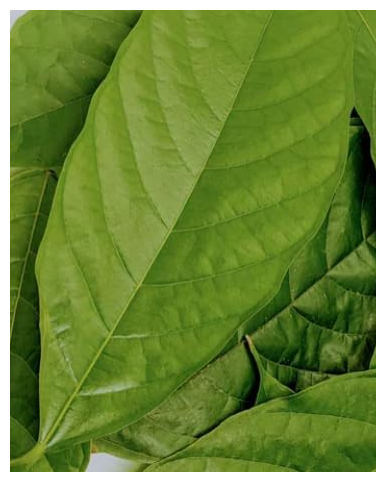

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(crop)
plt.axis("off")
plt.show()

In [ ]:
img_tensor = transform_mobile(crop).unsqueeze(0)

with torch.no_grad():
    feat = mobilenet(img_tensor).numpy().flatten()

print("Feature length:", len(feat))

Feature length: 576


In [ ]:
healthy_score = feat @ beta_healthy
cssvd_score = feat @ beta_cssvd
anthracnose_score = feat @ beta_anthracnose

scores = {
    "healthy": healthy_score,
    "cssvd": cssvd_score,
    "anthracnose": anthracnose_score
}

prediction = max(scores, key=scores.get)

print("\nPrediction:", prediction)
print("\nScores:")
print(scores)


Prediction: cssvd

Scores:
{'healthy': np.float64(-5.371403238795207), 'cssvd': np.float64(-0.8279452456491709), 'anthracnose': np.float64(-8.788397926296083)}


In [ ]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(
    model_path="/content/drive/MyDrive/TinyBayes/run_2000/yolo_runs/cocoa_yolov8n/weights/best_saved_model/best_float32.tflite"
)

interpreter.allocate_tensors()

output = interpreter.get_output_details()[0]

print(output)

{'name': 'Identity', 'index': 408, 'shape': array([   1,    7, 8400], dtype=int32), 'shape_signature': array([   1,    7, 8400], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}


In [ ]:
import tensorflow as tf
import cv2
import numpy as np

interpreter = tf.lite.Interpreter(
    model_path="/content/drive/MyDrive/TinyBayes/run_2000/yolo_runs/cocoa_yolov8n/weights/best_saved_model/best_float32.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

image = cv2.imread("519ISHDCeDL.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

img = cv2.resize(image, (640,640)).astype(np.float32) / 255.0
img = np.expand_dims(img, axis=0)

interpreter.set_tensor(input_details[0]["index"], img)
interpreter.invoke()

output = interpreter.get_tensor(output_details[0]["index"])

print(output.shape)

for i in range(5):
    print(output[0,:,i])

(1, 7, 8400)
[  0.0029289    0.010309    0.046066     0.02823  5.8891e-06  5.7506e-06  6.6086e-06]
[   0.032128    0.013296    0.086096    0.025141  4.9335e-06  4.4203e-06  5.0121e-06]
[   0.047049    0.013963     0.12044    0.027637  4.9964e-06  3.9915e-06  4.7469e-06]
[   0.055548    0.014994     0.13422    0.029757  7.2427e-06  5.1216e-06   5.995e-06]
[   0.059748    0.015008     0.16293    0.029822  1.1543e-05  7.1337e-06  8.4134e-06]


Best confidence: 0.2336137
Class: 0
Box: [np.float32(86.253784), np.float32(-2.4783325), np.float32(453.18903), np.float32(459.95575)]


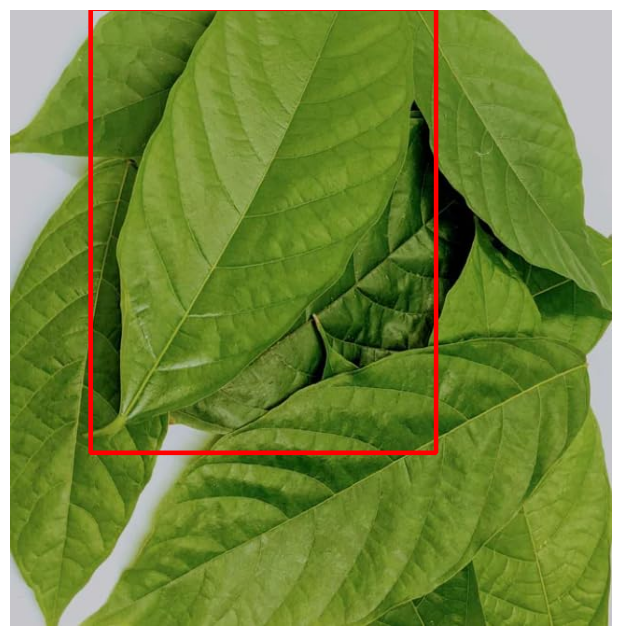

In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

MODEL_PATH = "/content/drive/MyDrive/TinyBayes/run_2000/yolo_runs/cocoa_yolov8n/weights/best_saved_model/best_float16.tflite"
IMAGE_PATH = "519ISHDCeDL.jpg"   # change

interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

inp = interpreter.get_input_details()
out = interpreter.get_output_details()

img = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h0, w0 = img_rgb.shape[:2]

img640 = cv2.resize(img_rgb, (640,640))
img640 = img640.astype(np.float32)/255.0
img640 = np.expand_dims(img640, axis=0)

interpreter.set_tensor(inp[0]["index"], img640)
interpreter.invoke()

pred = interpreter.get_tensor(out[0]["index"])[0]

best_conf = -1
best_box = None
best_class = None

for i in range(pred.shape[1]):

    xc = pred[0,i]
    yc = pred[1,i]
    bw = pred[2,i]
    bh = pred[3,i]

    cls_scores = pred[4:,i]

    cls_id = np.argmax(cls_scores)
    conf = cls_scores[cls_id]

    if conf > best_conf:

        best_conf = conf
        best_class = cls_id

        xc *= 640
        yc *= 640
        bw *= 640
        bh *= 640

        x1 = xc - bw/2
        y1 = yc - bh/2
        x2 = xc + bw/2
        y2 = yc + bh/2

        best_box = [x1,y1,x2,y2]

print("Best confidence:", best_conf)
print("Class:", best_class)
print("Box:", best_box)

sx = w0 / 640
sy = h0 / 640

x1,y1,x2,y2 = best_box

x1 = int(x1*sx)
y1 = int(y1*sy)
x2 = int(x2*sx)
y2 = int(y2*sy)

vis = img_rgb.copy()

cv2.rectangle(
    vis,
    (x1,y1),
    (x2,y2),
    (255,0,0),
    4
)

plt.figure(figsize=(8,8))
plt.imshow(vis)
plt.axis("off")
plt.show()

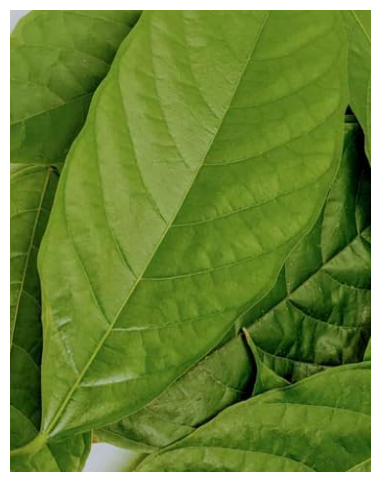

In [ ]:
# crop using YOLO box

crop = img_rgb[
    max(0,y1):min(h0,y2),
    max(0,x1):min(w0,x2)
]

plt.figure(figsize=(6,6))
plt.imshow(crop)
plt.axis("off")
plt.show()

In [ ]:
img_tensor = transform_mobile(crop).unsqueeze(0)

with torch.no_grad():
    feat = mobilenet(img_tensor).numpy().flatten()

healthy_score = feat @ beta_healthy
cssvd_score = feat @ beta_cssvd
anthracnose_score = feat @ beta_anthracnose

scores = {
    "healthy": healthy_score,
    "cssvd": cssvd_score,
    "anthracnose": anthracnose_score
}

prediction = max(scores, key=scores.get)

print("Prediction:", prediction)
print(scores)

Prediction: cssvd
{'healthy': np.float64(-5.741401564498468), 'cssvd': np.float64(-0.1493836524598917), 'anthracnose': np.float64(-9.42989028658986)}


In [ ]:
# ============================================================
# ANDROID APP ACCURACY EVALUATION (WITHOUT YOLO)
# ============================================================

import json
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

MODEL_PATH = "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.tflite"
COEFF_PATH = "/content/drive/MyDrive/TinyBayes/run_2000/jacobi_coefficients.json"

# ------------------------------------------------------------
# Load TFLite MobileNet
# ------------------------------------------------------------

interpreter = tf.lite.Interpreter(
    model_path=MODEL_PATH
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input:", input_details[0]["shape"])
print("Output:", output_details[0]["shape"])

# ------------------------------------------------------------
# Load Jacobi coefficients
# ------------------------------------------------------------

with open(COEFF_PATH, "r") as f:
    coeffs = json.load(f)

healthy = np.array(coeffs["healthy"], dtype=np.float32)
cssvd = np.array(coeffs["cssvd"], dtype=np.float32)
anthracnose = np.array(coeffs["anthracnose"], dtype=np.float32)

print("Healthy coeffs:", len(healthy))
print("CSSVD coeffs:", len(cssvd))
print("Anthracnose coeffs:", len(anthracnose))

# ------------------------------------------------------------
# Android-equivalent prediction function
# ------------------------------------------------------------

def android_predict(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (224, 224)
    )

    image = image.astype(np.float32) / 255.0

    image[:,:,0] = (
        image[:,:,0] - 0.485
    ) / 0.229

    image[:,:,1] = (
        image[:,:,1] - 0.456
    ) / 0.224

    image[:,:,2] = (
        image[:,:,2] - 0.406
    ) / 0.225

    input_tensor = np.expand_dims(
        image,
        axis=0
    ).astype(np.float32)

    interpreter.set_tensor(
        input_details[0]["index"],
        input_tensor
    )

    interpreter.invoke()

    features = interpreter.get_tensor(
        output_details[0]["index"]
    )[0]

    healthy_score = np.dot(
        features,
        healthy
    )

    cssvd_score = np.dot(
        features,
        cssvd
    )

    anthracnose_score = np.dot(
        features,
        anthracnose
    )

    scores = {
        "healthy": healthy_score,
        "cssvd": cssvd_score,
        "anthracnose": anthracnose_score
    }

    return max(
        scores,
        key=scores.get
    )

# ------------------------------------------------------------
# Run on validation set
# ------------------------------------------------------------

y_true = []
y_pred = []

for _, row in tqdm(
    validation_data.iterrows(),
    total=len(validation_data)
):

    image_path = os.path.join(
        IMAGE_DIR_VAL,
        row["Image_ID"]
    )

    pred = android_predict(
        image_path
    )

    if pred is None:
        continue

    y_true.append(
        row["class"]
    )

    y_pred.append(
        pred
    )

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

acc = accuracy_score(
    y_true,
    y_pred
)

print("\n")
print("=" * 60)
print("ANDROID APP ACCURACY")
print("=" * 60)

print(f"Accuracy: {acc:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        labels=[
            "healthy",
            "cssvd",
            "anthracnose"
        ]
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "healthy",
        "cssvd",
        "anthracnose"
    ]
)

print("\nConfusion Matrix:\n")
print(cm)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Input: [  1 224 224   3]
Output: [  1 576]
Healthy coeffs: 576
CSSVD coeffs: 576
Anthracnose coeffs: 576


100%|██████████| 500/500 [01:25<00:00,  5.88it/s]



ANDROID APP ACCURACY
Accuracy: 0.6540

Classification Report:

              precision    recall  f1-score   support

     healthy       0.79      0.35      0.48       167
       cssvd       0.63      0.83      0.72       166
 anthracnose       0.63      0.78      0.70       167

    accuracy                           0.65       500
   macro avg       0.68      0.65      0.63       500
weighted avg       0.68      0.65      0.63       500


Confusion Matrix:

[[ 58  53  56]
 [  7 138  21]
 [  8  28 131]]


In [ ]:
# ============================================================
# ANDROID APP + GROUND TRUTH CROP EVALUATION
# ============================================================

import json
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

MODEL_PATH = "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.tflite"
COEFF_PATH = "/content/drive/MyDrive/TinyBayes/run_2000/jacobi_coefficients_tflite.json"

# ------------------------------------------------------------
# Load TFLite MobileNet
# ------------------------------------------------------------

interpreter = tf.lite.Interpreter(
    model_path=MODEL_PATH
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ------------------------------------------------------------
# Load Jacobi coefficients
# ------------------------------------------------------------

with open(COEFF_PATH, "r") as f:
    coeffs = json.load(f)

healthy = np.array(coeffs["healthy"], dtype=np.float32)
cssvd = np.array(coeffs["cssvd"], dtype=np.float32)
anthracnose = np.array(coeffs["anthracnose"], dtype=np.float32)

# ------------------------------------------------------------
# Create lookup table from Train.csv
# ------------------------------------------------------------

bbox_lookup = {}

for _, row in df_train.iterrows():

    bbox_lookup[row["Image_ID"]] = (
        int(row["xmin"]),
        int(row["ymin"]),
        int(row["xmax"]),
        int(row["ymax"])
    )

# ------------------------------------------------------------
# Android prediction with GT crop
# ------------------------------------------------------------

def android_predict_with_crop(image_path, image_id):

    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # ----------------------------------
    # Ground truth crop
    # ----------------------------------

    if image_id in bbox_lookup:

        xmin, ymin, xmax, ymax = bbox_lookup[image_id]

        xmin = max(0, xmin)
        ymin = max(0, ymin)

        xmax = min(
            image.shape[1],
            xmax
        )

        ymax = min(
            image.shape[0],
            ymax
        )

        crop = image[
            ymin:ymax,
            xmin:xmax
        ]

        if crop.size > 0:
            image = crop

    # ----------------------------------
    # Same preprocessing as Android
    # ----------------------------------

    image = cv2.resize(
        image,
        (224, 224)
    )

    image = image.astype(np.float32)

    image /= 255.0

    image[:, :, 0] = (
        image[:, :, 0] - 0.485
    ) / 0.229

    image[:, :, 1] = (
        image[:, :, 1] - 0.456
    ) / 0.224

    image[:, :, 2] = (
        image[:, :, 2] - 0.406
    ) / 0.225

    input_tensor = np.expand_dims(
        image,
        axis=0
    ).astype(np.float32)

    interpreter.set_tensor(
        input_details[0]["index"],
        input_tensor
    )

    interpreter.invoke()

    features = interpreter.get_tensor(
        output_details[0]["index"]
    )[0]

    healthy_score = np.dot(
        features,
        healthy
    )

    cssvd_score = np.dot(
        features,
        cssvd
    )

    anthracnose_score = np.dot(
        features,
        anthracnose
    )

    scores = {
        "healthy": healthy_score,
        "cssvd": cssvd_score,
        "anthracnose": anthracnose_score
    }

    return max(
        scores,
        key=scores.get
    )

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

y_true = []
y_pred = []

for _, row in tqdm(
    validation_data.iterrows(),
    total=len(validation_data)
):

    image_id = row["Image_ID"]

    image_path = os.path.join(
        IMAGE_DIR_VAL,
        image_id
    )

    pred = android_predict_with_crop(
        image_path,
        image_id
    )

    if pred is None:
        continue

    y_true.append(
        row["class"]
    )

    y_pred.append(
        pred
    )

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

acc = accuracy_score(
    y_true,
    y_pred
)

print("\n")
print("=" * 60)
print("ANDROID APP + GROUND TRUTH CROP")
print("=" * 60)

print(f"Accuracy: {acc:.4f}")

print(
    classification_report(
        y_true,
        y_pred,
        labels=[
            "healthy",
            "cssvd",
            "anthracnose"
        ]
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "healthy",
        "cssvd",
        "anthracnose"
    ]
)

print("\nConfusion Matrix:\n")
print(cm)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
100%|██████████| 500/500 [10:44<00:00,  1.29s/it]



ANDROID APP + GROUND TRUTH CROP
Accuracy: 0.7700
              precision    recall  f1-score   support

     healthy       0.80      0.71      0.75       167
       cssvd       0.73      0.82      0.77       166
 anthracnose       0.79      0.78      0.79       167

    accuracy                           0.77       500
   macro avg       0.77      0.77      0.77       500
weighted avg       0.77      0.77      0.77       500


Confusion Matrix:

[[118  27  22]
 [ 17 136  13]
 [ 13  23 131]]


In [ ]:
# ============================================================
# PYTORCH vs TFLITE FEATURE COMPARISON
# ============================================================

import tensorflow as tf
import json
import cv2
import numpy as np
import torch

MODEL_PATH = "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.tflite"

# ------------------------------------------------------------
# Load TFLite model
# ------------------------------------------------------------

interpreter = tf.lite.Interpreter(
    model_path=MODEL_PATH
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ------------------------------------------------------------
# Load PyTorch MobileNet
# ------------------------------------------------------------

mobilenet_pt = mobilenet_v3_small(
    weights=MobileNet_V3_Small_Weights.DEFAULT
)

mobilenet_pt.classifier = torch.nn.Identity()
mobilenet_pt.eval()
mobilenet_pt.to(device)

transform_mobile = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ------------------------------------------------------------
# Pick one validation image
# ------------------------------------------------------------

sample_row = validation_data.iloc[0]

image_id = sample_row["Image_ID"]

print("Image:", image_id)

image_path = os.path.join(
    IMAGE_DIR_VAL,
    image_id
)

image = cv2.imread(image_path)
image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

# ------------------------------------------------------------
# Ground truth crop
# ------------------------------------------------------------

gt_row = df_train[
    df_train["Image_ID"] == image_id
].iloc[0]

xmin = int(gt_row["xmin"])
ymin = int(gt_row["ymin"])
xmax = int(gt_row["xmax"])
ymax = int(gt_row["ymax"])

crop = image[
    ymin:ymax,
    xmin:xmax
]

if crop.size == 0:
    crop = image

print("Crop shape:", crop.shape)

# ------------------------------------------------------------
# PYTORCH FEATURES
# ------------------------------------------------------------

pt_tensor = transform_mobile(crop) \
    .unsqueeze(0) \
    .to(device)

with torch.no_grad():

    pt_features = mobilenet_pt(
        pt_tensor
    ).cpu().numpy().flatten()

# ------------------------------------------------------------
# TFLITE FEATURES
# ------------------------------------------------------------

img = cv2.resize(
    crop,
    (224,224)
).astype(np.float32)

img /= 255.0

img[:,:,0] = (
    img[:,:,0] - 0.485
) / 0.229

img[:,:,1] = (
    img[:,:,1] - 0.456
) / 0.224

img[:,:,2] = (
    img[:,:,2] - 0.406
) / 0.225

input_tensor = np.expand_dims(
    img,
    axis=0
).astype(np.float32)

interpreter.set_tensor(
    input_details[0]["index"],
    input_tensor
)

interpreter.invoke()

tflite_features = interpreter.get_tensor(
    output_details[0]["index"]
)[0]

# ------------------------------------------------------------
# COMPARE
# ------------------------------------------------------------

diff = np.abs(
    pt_features - tflite_features
)

print("\n")
print("="*60)
print("FEATURE COMPARISON")
print("="*60)

print("Feature length:", len(pt_features))

print(
    "Mean abs diff:",
    np.mean(diff)
)

print(
    "Max abs diff:",
    np.max(diff)
)

print(
    "Min abs diff:",
    np.min(diff)
)

print(
    "PyTorch mean:",
    np.mean(pt_features)
)

print(
    "TFLite mean:",
    np.mean(tflite_features)
)

# ------------------------------------------------------------
# COSINE SIMILARITY
# ------------------------------------------------------------

cosine = np.dot(
    pt_features,
    tflite_features
) / (
    np.linalg.norm(pt_features)
    *
    np.linalg.norm(tflite_features)
)

print(
    "\nCosine Similarity:",
    cosine
)

# ------------------------------------------------------------
# FIRST 20 FEATURES
# ------------------------------------------------------------

print("\nFirst 20 PyTorch Features:")
print(pt_features[:20])

print("\nFirst 20 TFLite Features:")
print(tflite_features[:20])

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 94.7MB/s]


Image: ID_OTgt1c.jpg
Crop shape: (1629, 889, 3)


FEATURE COMPARISON
Feature length: 576
Mean abs diff: 0.084186725
Max abs diff: 0.91644704
Min abs diff: 2.1706335e-05
PyTorch mean: 0.24171822
TFLite mean: 0.26794457

Cosine Similarity: 0.9710121

First 20 PyTorch Features:
[    0.16425   0.0025345    -0.10245   0.0056447      1.3852   -0.027415   -0.083319   -0.051821     0.52491    -0.12657    0.077278    0.092927     0.58312     0.82365      0.2155   -0.091851    -0.09045     0.12948     0.34077   -0.058189]

First 20 TFLite Features:
[    0.21934   -0.016505   -0.034435    0.055924       1.864      0.1693   -0.048897   -0.075776     0.42332    -0.11542    0.034522     0.14389      1.2318     0.69664     0.35891   -0.035633   -0.097576     0.23749     0.32307   -0.077464]


In [ ]:
import tensorflow as tf
import json

MODEL_PATH = "/content/drive/MyDrive/TinyBayes/run_2000/mobilenet_v3_small.tflite"

interpreter = tf.lite.Interpreter(
    model_path=MODEL_PATH
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

train_features = []

for _, row in tqdm(
    df_train_balanced.iterrows(),
    total=len(df_train_balanced)
):

    image_path = os.path.join(
        IMAGE_DIR_TRAIN,
        row["Image_ID"]
    )

    image = cv2.imread(image_path)

    if image is None:
        continue

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    xmin = max(0, int(row["xmin"]))
    ymin = max(0, int(row["ymin"]))

    xmax = min(
        image.shape[1],
        int(row["xmax"])
    )

    ymax = min(
        image.shape[0],
        int(row["ymax"])
    )

    crop = image[
        ymin:ymax,
        xmin:xmax
    ]

    if crop.size == 0:
        crop = image

    crop = cv2.resize(
        crop,
        (224,224)
    ).astype(np.float32)

    crop /= 255.0

    crop[:,:,0] = (
        crop[:,:,0] - 0.485
    ) / 0.229

    crop[:,:,1] = (
        crop[:,:,1] - 0.456
    ) / 0.224

    crop[:,:,2] = (
        crop[:,:,2] - 0.406
    ) / 0.225

    input_tensor = np.expand_dims(
        crop,
        axis=0
    ).astype(np.float32)

    interpreter.set_tensor(
        input_details[0]["index"],
        input_tensor
    )

    interpreter.invoke()

    feat = interpreter.get_tensor(
        output_details[0]["index"]
    )[0]

    train_features.append([
        *feat,
        row["class"]
    ])

cols = [
    f"feat_{i}"
    for i in range(576)
]

cols.append("label")

train_tflite_df = pd.DataFrame(
    train_features,
    columns=cols
)

print(train_tflite_df.shape)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
100%|██████████| 2000/2000 [37:48<00:00,  1.13s/it]


(2000, 577)


In [ ]:
X_train_tflite = train_tflite_df.drop(
    columns=["label"]
)

Y_train_tflite = train_tflite_df["label"]

y_one_hot = pd.get_dummies(
    Y_train_tflite
)

y_healthy = np.array(
    y_one_hot["healthy"]
)

y_cssvd = np.array(
    y_one_hot["cssvd"]
)

y_anthracnose = np.array(
    y_one_hot["anthracnose"]
)

a = b = 1/2000
k = 1

eta_healthy = np.log(
    (y_healthy + a) /
    (1 + k*b)
)

eta_cssvd = np.log(
    (y_cssvd + a) /
    (1 + k*b)
)

eta_anthracnose = np.log(
    (y_anthracnose + a) /
    (1 + k*b)
)

X = X_train_tflite.values

beta_healthy = (
    inv(X.T @ X)
    @
    (X.T @ eta_healthy)
)

beta_cssvd = (
    inv(X.T @ X)
    @
    (X.T @ eta_cssvd)
)

beta_anthracnose = (
    inv(X.T @ X)
    @
    (X.T @ eta_anthracnose)
)

print("trained")

trained


In [ ]:
new_coeffs = {
    "healthy":
        beta_healthy.tolist(),

    "cssvd":
        beta_cssvd.tolist(),

    "anthracnose":
        beta_anthracnose.tolist()
}

NEW_JSON_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "jacobi_coefficients_tflite.json"
)

with open(
    NEW_JSON_PATH,
    "w"
) as f:

    json.dump(
        new_coeffs,
        f
    )

print(
    "Saved:",
    NEW_JSON_PATH
)

Saved: /content/drive/MyDrive/TinyBayes/run_2000/jacobi_coefficients_tflite.json


In [ ]:
# ============================================================
# ANDROID APP ACCURACY
# FULL IMAGE + NEW TFLITE JACOBI
# ============================================================

import tensorflow as tf
import json

MODEL_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "mobilenet_v3_small.tflite"
)

COEFF_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "jacobi_coefficients_tflite.json"
)

# ------------------------------------------------------------
# Load TFLite model
# ------------------------------------------------------------

interpreter = tf.lite.Interpreter(
    model_path=MODEL_PATH
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ------------------------------------------------------------
# Load NEW coefficients
# ------------------------------------------------------------

with open(COEFF_PATH, "r") as f:
    coeffs = json.load(f)

healthy = np.array(
    coeffs["healthy"],
    dtype=np.float32
)

cssvd = np.array(
    coeffs["cssvd"],
    dtype=np.float32
)

anthracnose = np.array(
    coeffs["anthracnose"],
    dtype=np.float32
)

# ------------------------------------------------------------
# Android prediction function
# ------------------------------------------------------------

def android_predict_full_image(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # SAME AS APK

    image = cv2.resize(
        image,
        (224,224)
    ).astype(np.float32)

    image /= 255.0

    image[:,:,0] = (
        image[:,:,0] - 0.485
    ) / 0.229

    image[:,:,1] = (
        image[:,:,1] - 0.456
    ) / 0.224

    image[:,:,2] = (
        image[:,:,2] - 0.406
    ) / 0.225

    input_tensor = np.expand_dims(
        image,
        axis=0
    ).astype(np.float32)

    interpreter.set_tensor(
        input_details[0]["index"],
        input_tensor
    )

    interpreter.invoke()

    features = interpreter.get_tensor(
        output_details[0]["index"]
    )[0]

    healthy_score = np.dot(
        features,
        healthy
    )

    cssvd_score = np.dot(
        features,
        cssvd
    )

    anthracnose_score = np.dot(
        features,
        anthracnose
    )

    scores = {
        "healthy": healthy_score,
        "cssvd": cssvd_score,
        "anthracnose": anthracnose_score
    }

    return max(
        scores,
        key=scores.get
    )


# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

y_true = []
y_pred = []

for _, row in tqdm(
    validation_data.iterrows(),
    total=len(validation_data)
):

    image_path = os.path.join(
        IMAGE_DIR_VAL,
        row["Image_ID"]
    )

    pred = android_predict_full_image(
        image_path
    )

    if pred is None:
        continue

    y_true.append(
        row["class"]
    )

    y_pred.append(
        pred
    )

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

acc = accuracy_score(
    y_true,
    y_pred
)

print("\n")
print("=" * 60)
print("ANDROID APP")
print("FULL IMAGE + NEW TFLITE JACOBI")
print("=" * 60)

print(f"Accuracy: {acc:.4f}")

print(
    classification_report(
        y_true,
        y_pred,
        labels=[
            "healthy",
            "cssvd",
            "anthracnose"
        ]
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "healthy",
        "cssvd",
        "anthracnose"
    ]
)

print("\nConfusion Matrix:\n")
print(cm)

In [ ]:
# ============================================================
# ANDROID APP ACCURACY
# FULL IMAGE + NEW TFLITE JACOBI
# ============================================================

import tensorflow as tf
import json

MODEL_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "mobilenet_v3_small.tflite"
)

COEFF_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "jacobi_coefficients_tflite.json"
)

# ------------------------------------------------------------
# Load TFLite model
# ------------------------------------------------------------

interpreter = tf.lite.Interpreter(
    model_path=MODEL_PATH
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ------------------------------------------------------------
# Load NEW coefficients
# ------------------------------------------------------------

with open(COEFF_PATH, "r") as f:
    coeffs = json.load(f)

healthy = np.array(
    coeffs["healthy"],
    dtype=np.float32
)

cssvd = np.array(
    coeffs["cssvd"],
    dtype=np.float32
)

anthracnose = np.array(
    coeffs["anthracnose"],
    dtype=np.float32
)

# ------------------------------------------------------------
# Android prediction function
# ------------------------------------------------------------

# def android_predict_full_image(image_path):

#     image = cv2.imread(image_path)

#     if image is None:
#         return None

#     image = cv2.cvtColor(
#         image,
#         cv2.COLOR_BGR2RGB
#     )

#     # SAME AS APK

#     image = cv2.resize(
#         image,
#         (224,224)
#     ).astype(np.float32)

#     image /= 255.0

#     image[:,:,0] = (
#         image[:,:,0] - 0.485
#     ) / 0.229

#     image[:,:,1] = (
#         image[:,:,1] - 0.456
#     ) / 0.224

#     image[:,:,2] = (
#         image[:,:,2] - 0.406
#     ) / 0.225

#     input_tensor = np.expand_dims(
#         image,
#         axis=0
#     ).astype(np.float32)

#     interpreter.set_tensor(
#         input_details[0]["index"],
#         input_tensor
#     )

#     interpreter.invoke()

#     features = interpreter.get_tensor(
#         output_details[0]["index"]
#     )[0]

#     healthy_score = np.dot(
#         features,
#         healthy
#     )

#     cssvd_score = np.dot(
#         features,
#         cssvd
#     )

#     anthracnose_score = np.dot(
#         features,
#         anthracnose
#     )

#     scores = {
#         "healthy": healthy_score,
#         "cssvd": cssvd_score,
#         "anthracnose": anthracnose_score
#     }

#     return max(
#         scores,
#         key=scores.get
#     )

def android_predict_center_crop(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    h, w = image.shape[:2]

    # --------------------------------
    # Center crop (80%)
    # --------------------------------

    crop_w = int(w * 0.8)
    crop_h = int(h * 0.8)

    x1 = (w - crop_w) // 2
    y1 = (h - crop_h) // 2

    x2 = x1 + crop_w
    y2 = y1 + crop_h

    image = image[y1:y2, x1:x2]

    # --------------------------------
    # Same preprocessing as Android
    # --------------------------------

    image = cv2.resize(
        image,
        (224, 224)
    ).astype(np.float32)

    image /= 255.0

    image[:, :, 0] = (
        image[:, :, 0] - 0.485
    ) / 0.229

    image[:, :, 1] = (
        image[:, :, 1] - 0.456
    ) / 0.224

    image[:, :, 2] = (
        image[:, :, 2] - 0.406
    ) / 0.225

    input_tensor = np.expand_dims(
        image,
        axis=0
    ).astype(np.float32)

    interpreter.set_tensor(
        input_details[0]["index"],
        input_tensor
    )

    interpreter.invoke()

    features = interpreter.get_tensor(
        output_details[0]["index"]
    )[0]

    healthy_score = np.dot(
        features,
        healthy
    )

    cssvd_score = np.dot(
        features,
        cssvd
    )

    anthracnose_score = np.dot(
        features,
        anthracnose
    )

    scores = {
        "healthy": healthy_score,
        "cssvd": cssvd_score,
        "anthracnose": anthracnose_score
    }

    return max(
        scores,
        key=scores.get
    )

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

y_true = []
y_pred = []

for _, row in tqdm(
    validation_data.iterrows(),
    total=len(validation_data)
):

    image_path = os.path.join(
        IMAGE_DIR_VAL,
        row["Image_ID"]
    )

    # pred = android_predict_full_image(
    #     image_path
    # )

    pred = android_predict_center_crop(
        image_path
    )

    if pred is None:
        continue

    y_true.append(
        row["class"]
    )

    y_pred.append(
        pred
    )

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

acc = accuracy_score(
    y_true,
    y_pred
)

print("\n")
print("=" * 60)
print("ANDROID APP")
print("FULL IMAGE + NEW TFLITE JACOBI")
print("=" * 60)

print(f"Accuracy: {acc:.4f}")

print(
    classification_report(
        y_true,
        y_pred,
        labels=[
            "healthy",
            "cssvd",
            "anthracnose"
        ]
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "healthy",
        "cssvd",
        "anthracnose"
    ]
)

print("\nConfusion Matrix:\n")
print(cm)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
100%|██████████| 500/500 [00:43<00:00, 11.59it/s]



ANDROID APP
FULL IMAGE + NEW TFLITE JACOBI
Accuracy: 0.7460
              precision    recall  f1-score   support

     healthy       0.79      0.60      0.68       167
       cssvd       0.70      0.84      0.76       166
 anthracnose       0.76      0.80      0.78       167

    accuracy                           0.75       500
   macro avg       0.75      0.75      0.74       500
weighted avg       0.75      0.75      0.74       500


Confusion Matrix:

[[101  37  29]
 [ 15 139  12]
 [ 12  22 133]]


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import os
from tqdm import tqdm

MODEL_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "mobilenet_v3_small.tflite"
)

interpreter = tf.lite.Interpreter(
    model_path=MODEL_PATH
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

full_train_features = []

for _, row in tqdm(
    df_train_balanced.iterrows(),
    total=len(df_train_balanced)
):

    image_path = os.path.join(
        IMAGE_DIR_TRAIN,
        row["Image_ID"]
    )

    image = cv2.imread(image_path)

    if image is None:
        continue

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # FULL IMAGE
    image = cv2.resize(
        image,
        (224,224)
    ).astype(np.float32)

    image /= 255.0

    image[:,:,0] = (
        image[:,:,0] - 0.485
    ) / 0.229

    image[:,:,1] = (
        image[:,:,1] - 0.456
    ) / 0.224

    image[:,:,2] = (
        image[:,:,2] - 0.406
    ) / 0.225

    input_tensor = np.expand_dims(
        image,
        axis=0
    ).astype(np.float32)

    interpreter.set_tensor(
        input_details[0]["index"],
        input_tensor
    )

    interpreter.invoke()

    feat = interpreter.get_tensor(
        output_details[0]["index"]
    )[0]

    full_train_features.append([
        *feat,
        row["class"]
    ])

columns = [
    f"feat_{i}"
    for i in range(576)
]

columns.append("label")

full_train_df = pd.DataFrame(
    full_train_features,
    columns=columns
)

print(full_train_df.shape)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
100%|██████████| 2000/2000 [18:59<00:00,  1.76it/s]


(2000, 577)


In [ ]:
from numpy.linalg import inv
import json

X_train = full_train_df.drop(
    columns=["label"]
)

Y_train = full_train_df["label"]

y_one_hot = pd.get_dummies(
    Y_train
)

y_healthy = np.array(
    y_one_hot["healthy"]
)

y_cssvd = np.array(
    y_one_hot["cssvd"]
)

y_anthracnose = np.array(
    y_one_hot["anthracnose"]
)

a = b = 1/2000
k = 1

eta_healthy = np.log(
    (y_healthy + a) /
    (1 + k*b)
)

eta_cssvd = np.log(
    (y_cssvd + a) /
    (1 + k*b)
)

eta_anthracnose = np.log(
    (y_anthracnose + a) /
    (1 + k*b)
)

X = X_train.values

beta_healthy = (
    inv(X.T @ X)
    @
    (X.T @ eta_healthy)
)

beta_cssvd = (
    inv(X.T @ X)
    @
    (X.T @ eta_cssvd)
)

beta_anthracnose = (
    inv(X.T @ X)
    @
    (X.T @ eta_anthracnose)
)

new_coeffs = {
    "healthy":
        beta_healthy.tolist(),

    "cssvd":
        beta_cssvd.tolist(),

    "anthracnose":
        beta_anthracnose.tolist()
}

FULL_IMAGE_JSON = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "jacobi_coefficients_full_image.json"
)

with open(
    FULL_IMAGE_JSON,
    "w"
) as f:

    json.dump(
        new_coeffs,
        f
    )

print(
    "Saved:",
    FULL_IMAGE_JSON
)

Saved: /content/drive/MyDrive/TinyBayes/run_2000/jacobi_coefficients_full_image.json


In [ ]:
# ============================================================
# ANDROID APP ACCURACY
# FULL IMAGE TRAINED JACOBI
# ============================================================

import tensorflow as tf
import json

MODEL_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "mobilenet_v3_small.tflite"
)

COEFF_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "jacobi_coefficients_full_image.json"
)

# ------------------------------------------------------------
# Load TFLite model
# ------------------------------------------------------------

interpreter = tf.lite.Interpreter(
    model_path=MODEL_PATH
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ------------------------------------------------------------
# Load coefficients
# ------------------------------------------------------------

with open(COEFF_PATH, "r") as f:
    coeffs = json.load(f)

healthy = np.array(
    coeffs["healthy"],
    dtype=np.float32
)

cssvd = np.array(
    coeffs["cssvd"],
    dtype=np.float32
)

anthracnose = np.array(
    coeffs["anthracnose"],
    dtype=np.float32
)

# ------------------------------------------------------------
# Android prediction function
# ------------------------------------------------------------

def android_predict_full_image(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # SAME AS CURRENT APK

    image = cv2.resize(
        image,
        (224, 224)
    ).astype(np.float32)

    image /= 255.0

    image[:, :, 0] = (
        image[:, :, 0] - 0.485
    ) / 0.229

    image[:, :, 1] = (
        image[:, :, 1] - 0.456
    ) / 0.224

    image[:, :, 2] = (
        image[:, :, 2] - 0.406
    ) / 0.225

    input_tensor = np.expand_dims(
        image,
        axis=0
    ).astype(np.float32)

    interpreter.set_tensor(
        input_details[0]["index"],
        input_tensor
    )

    interpreter.invoke()

    features = interpreter.get_tensor(
        output_details[0]["index"]
    )[0]

    healthy_score = np.dot(
        features,
        healthy
    )

    cssvd_score = np.dot(
        features,
        cssvd
    )

    anthracnose_score = np.dot(
        features,
        anthracnose
    )

    scores = {
        "healthy": healthy_score,
        "cssvd": cssvd_score,
        "anthracnose": anthracnose_score
    }

    return max(
        scores,
        key=scores.get
    )

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

y_true = []
y_pred = []

for _, row in tqdm(
    validation_data.iterrows(),
    total=len(validation_data)
):

    image_path = os.path.join(
        IMAGE_DIR_VAL,
        row["Image_ID"]
    )

    pred = android_predict_full_image(
        image_path
    )

    if pred is None:
        continue

    y_true.append(
        row["class"]
    )

    y_pred.append(
        pred
    )

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

acc = accuracy_score(
    y_true,
    y_pred
)

print("\n")
print("=" * 60)
print("ANDROID APP")
print("FULL IMAGE TRAINED JACOBI")
print("=" * 60)

print(f"Accuracy: {acc:.4f}")

print(
    classification_report(
        y_true,
        y_pred,
        labels=[
            "healthy",
            "cssvd",
            "anthracnose"
        ]
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "healthy",
        "cssvd",
        "anthracnose"
    ]
)

print("\nConfusion Matrix:\n")
print(cm)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
100%|██████████| 500/500 [05:01<00:00,  1.66it/s]



ANDROID APP
FULL IMAGE TRAINED JACOBI
Accuracy: 0.8320
              precision    recall  f1-score   support

     healthy       0.83      0.80      0.81       167
       cssvd       0.82      0.85      0.83       166
 anthracnose       0.85      0.84      0.85       167

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500


Confusion Matrix:

[[134  19  14]
 [ 14 141  11]
 [ 14  12 141]]


In [ ]:
# ============================================================
# TRAIN JACOBI USING ALL TRAINING IMAGES
# FULL IMAGE + TFLITE FEATURES
# DOES NOT OVERWRITE EXISTING FILES
# ============================================================

import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import os
import json

from tqdm import tqdm
from numpy.linalg import inv

MODEL_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "mobilenet_v3_small.tflite"
)

FEATURE_SAVE_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "full_train_features_all_images.csv"
)

COEFF_SAVE_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "jacobi_coefficients_all_images.json"
)

# ------------------------------------------------------------
# Training set = ALL images except validation images
# ------------------------------------------------------------

train_all = df_train[
    ~df_train["Image_ID"].isin(
        validation_data["Image_ID"]
    )
].copy()

print("Training images:", len(train_all))
print("Validation images:", len(validation_data))

# ------------------------------------------------------------
# Load TFLite
# ------------------------------------------------------------

interpreter = tf.lite.Interpreter(
    model_path=MODEL_PATH
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ------------------------------------------------------------
# Extract TFLite features
# ------------------------------------------------------------

all_features = []

for _, row in tqdm(
    train_all.iterrows(),
    total=len(train_all)
):

    image_path = os.path.join(
        IMAGE_DIR_TRAIN,
        row["Image_ID"]
    )

    image = cv2.imread(image_path)

    if image is None:
        continue

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (224,224)
    ).astype(np.float32)

    image /= 255.0

    image[:,:,0] = (
        image[:,:,0] - 0.485
    ) / 0.229

    image[:,:,1] = (
        image[:,:,1] - 0.456
    ) / 0.224

    image[:,:,2] = (
        image[:,:,2] - 0.406
    ) / 0.225

    input_tensor = np.expand_dims(
        image,
        axis=0
    ).astype(np.float32)

    interpreter.set_tensor(
        input_details[0]["index"],
        input_tensor
    )

    interpreter.invoke()

    feat = interpreter.get_tensor(
        output_details[0]["index"]
    )[0]

    all_features.append([
        *feat,
        row["class"]
    ])

columns = [
    f"feat_{i}"
    for i in range(576)
]

columns.append("label")

full_train_df_all = pd.DataFrame(
    all_features,
    columns=columns
)

full_train_df_all.to_csv(
    FEATURE_SAVE_PATH,
    index=False
)

print(
    "\nSaved features:",
    FEATURE_SAVE_PATH
)

# ------------------------------------------------------------
# Train Jacobi
# ------------------------------------------------------------

X_train = full_train_df_all.drop(
    columns=["label"]
)

Y_train = full_train_df_all["label"]

y_one_hot = pd.get_dummies(
    Y_train
)

y_healthy = np.array(
    y_one_hot["healthy"]
)

y_cssvd = np.array(
    y_one_hot["cssvd"]
)

y_anthracnose = np.array(
    y_one_hot["anthracnose"]
)

a = b = 1 / len(X_train)
k = 1

eta_healthy = np.log(
    (y_healthy + a) /
    (1 + k*b)
)

eta_cssvd = np.log(
    (y_cssvd + a) /
    (1 + k*b)
)

eta_anthracnose = np.log(
    (y_anthracnose + a) /
    (1 + k*b)
)

X = X_train.values

beta_healthy = (
    inv(X.T @ X)
    @
    (X.T @ eta_healthy)
)

beta_cssvd = (
    inv(X.T @ X)
    @
    (X.T @ eta_cssvd)
)

beta_anthracnose = (
    inv(X.T @ X)
    @
    (X.T @ eta_anthracnose)
)

coeffs = {

    "healthy":
        beta_healthy.tolist(),

    "cssvd":
        beta_cssvd.tolist(),

    "anthracnose":
        beta_anthracnose.tolist()
}

with open(
    COEFF_SAVE_PATH,
    "w"
) as f:

    json.dump(
        coeffs,
        f
    )

print(
    "\nSaved coefficients:",
    COEFF_SAVE_PATH
)

print(
    "\nTraining complete."
)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Training images: 8713
Validation images: 500


100%|██████████| 8713/8713 [44:38<00:00,  3.25it/s]



Saved features: /content/drive/MyDrive/TinyBayes/run_2000/full_train_features_all_images.csv

Saved coefficients: /content/drive/MyDrive/TinyBayes/run_2000/jacobi_coefficients_all_images.json

Training complete.


In [ ]:
# ============================================================
# ANDROID APP ACCURACY
# FULL IMAGE TRAINED JACOBI
# ============================================================

import tensorflow as tf
import json

MODEL_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "mobilenet_v3_small.tflite"
)

COEFF_PATH = (
    "/content/drive/MyDrive/TinyBayes/run_2000/"
    "jacobi_coefficients_all_images.json"
)

# ------------------------------------------------------------
# Load TFLite model
# ------------------------------------------------------------

interpreter = tf.lite.Interpreter(
    model_path=MODEL_PATH
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ------------------------------------------------------------
# Load coefficients
# ------------------------------------------------------------

with open(COEFF_PATH, "r") as f:
    coeffs = json.load(f)

healthy = np.array(
    coeffs["healthy"],
    dtype=np.float32
)

cssvd = np.array(
    coeffs["cssvd"],
    dtype=np.float32
)

anthracnose = np.array(
    coeffs["anthracnose"],
    dtype=np.float32
)

# ------------------------------------------------------------
# Android prediction function
# ------------------------------------------------------------

def android_predict_full_image(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # SAME AS CURRENT APK

    image = cv2.resize(
        image,
        (224, 224)
    ).astype(np.float32)

    image /= 255.0

    image[:, :, 0] = (
        image[:, :, 0] - 0.485
    ) / 0.229

    image[:, :, 1] = (
        image[:, :, 1] - 0.456
    ) / 0.224

    image[:, :, 2] = (
        image[:, :, 2] - 0.406
    ) / 0.225

    input_tensor = np.expand_dims(
        image,
        axis=0
    ).astype(np.float32)

    interpreter.set_tensor(
        input_details[0]["index"],
        input_tensor
    )

    interpreter.invoke()

    features = interpreter.get_tensor(
        output_details[0]["index"]
    )[0]

    healthy_score = np.dot(
        features,
        healthy
    )

    cssvd_score = np.dot(
        features,
        cssvd
    )

    anthracnose_score = np.dot(
        features,
        anthracnose
    )

    scores = {
        "healthy": healthy_score,
        "cssvd": cssvd_score,
        "anthracnose": anthracnose_score
    }

    return max(
        scores,
        key=scores.get
    )

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

y_true = []
y_pred = []

for _, row in tqdm(
    validation_data.iterrows(),
    total=len(validation_data)
):

    image_path = os.path.join(
        IMAGE_DIR_VAL,
        row["Image_ID"]
    )

    pred = android_predict_full_image(
        image_path
    )

    if pred is None:
        continue

    y_true.append(
        row["class"]
    )

    y_pred.append(
        pred
    )

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

acc = accuracy_score(
    y_true,
    y_pred
)

print("\n")
print("=" * 60)
print("ANDROID APP")
print("FULL IMAGE TRAINED JACOBI")
print("=" * 60)

print(f"Accuracy: {acc:.4f}")

print(
    classification_report(
        y_true,
        y_pred,
        labels=[
            "healthy",
            "cssvd",
            "anthracnose"
        ]
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "healthy",
        "cssvd",
        "anthracnose"
    ]
)

print("\nConfusion Matrix:\n")
print(cm)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
100%|██████████| 500/500 [01:39<00:00,  5.00it/s]



ANDROID APP
FULL IMAGE TRAINED JACOBI
Accuracy: 0.8360
              precision    recall  f1-score   support

     healthy       0.84      0.85      0.85       167
       cssvd       0.78      0.89      0.83       166
 anthracnose       0.91      0.77      0.83       167

    accuracy                           0.84       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500


Confusion Matrix:

[[142  17   8]
 [ 14 147   5]
 [ 13  25 129]]


# **Step 7: Train & Test Random Forest (All 576 Features)**

In [ ]:
time_rf_start = time.time()

# Load features
X_train = extracted_features_train.drop(columns=["label"])
Y_train = extracted_features_train["label"]
X_test_with_id = extracted_features_val
val_image_id = X_test_with_id["Image_ID"]
X_test = extracted_features_val.drop(columns=["Image_ID"])

# Train Random Forest
rf_cocoa = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cocoa.fit(X_train, Y_train)
y_pred_rf = rf_cocoa.predict(X_test)

time_rf_seconds = time.time() - time_rf_start

# Evaluate
df_eval_rf = pd.DataFrame({"Image_ID": val_image_id, "Predicted_Label": y_pred_rf})
df_eval_rf = df_eval_rf.merge(validation_data.drop_duplicates(subset="Image_ID"), on="Image_ID", how="left")

acc_rf = accuracy_score(df_eval_rf["class"], df_eval_rf["Predicted_Label"])
report_rf = classification_report(df_eval_rf["class"], df_eval_rf["Predicted_Label"], target_names=["healthy", "cssvd", "anthracnose"])
cm_rf = confusion_matrix(df_eval_rf["class"], df_eval_rf["Predicted_Label"], labels=["healthy", "cssvd", "anthracnose"])

print(f"Random Forest Accuracy: {acc_rf:.4f} | Time: {time_rf_seconds:.4f}s")
print(f"Classification Report:\n{report_rf}")
print(f"Confusion Matrix:\n{cm_rf}")


# **Step 8: Train & Test SVM (All 576 Features)**

In [ ]:
time_svm_start = time.time()

# Standardize ALL 576 features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_test)

# Train SVM on all 576 features
svm_cocoa = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_cocoa.fit(X_train_scaled, Y_train)
y_pred_svm = svm_cocoa.predict(X_val_scaled)

time_svm_seconds = time.time() - time_svm_start

# Evaluate
df_eval_svm = pd.DataFrame({"Image_ID": val_image_id, "Predicted_Label": y_pred_svm})
df_eval_svm = df_eval_svm.merge(validation_data.drop_duplicates(subset="Image_ID"), on="Image_ID", how="left")

acc_svm = accuracy_score(df_eval_svm["class"], df_eval_svm["Predicted_Label"])
report_svm = classification_report(df_eval_svm["class"], df_eval_svm["Predicted_Label"], target_names=["healthy", "cssvd", "anthracnose"])
cm_svm = confusion_matrix(df_eval_svm["class"], df_eval_svm["Predicted_Label"], labels=["healthy", "cssvd", "anthracnose"])

print(f"SVM Accuracy (all 576 features): {acc_svm:.4f} | Time: {time_svm_seconds:.4f}s")
print(f"Classification Report:\n{report_svm}")
print(f"Confusion Matrix:\n{cm_svm}")


# **Step 10: Jacobi-GP (All 576 Features)**


In [ ]:
time_jacobi_gp_start = time.time()

# ===== JACOBI PRIOR + GP — UNCHANGED MATH =====
y_train_labels = np.array(Y_train)
y_test_labels = np.array(df_eval_svm["class"])

y_dict = {}
y_test_dict = {}
for label in np.unique(y_train_labels):
    y_dict[f'y{label}'] = [1 if item == label else 0 for item in y_train_labels]
    y_test_dict[f'y{label}_test'] = [1 if item == label else 0 for item in y_test_labels]

# Jacobi prior hyperparameters
#consistent parameter choice is 1/n - as per theorem
a_gp = b_gp = 1 / 2000
k_gp = 1

# Use ALL 576 features
train_features = X_train
test_features = X_test

y_values = [y_dict[f'y{i}'] for i in np.unique(y_train_labels)]

# Compute eta_hat using Jacobi Prior (UNCHANGED)
eta_hat = []
for i in range(len(np.unique(y_train_labels))):
    eta = np.log((np.array(y_values[i]) + a_gp) / (1 + (k_gp * b_gp)))
    eta_hat.append(eta)

# GP kernel and fitting (UNCHANGED)
kernel = C(1.0, (1e-4, 1e1)) * RBF(1.0, (1e-4, 1e1))
gp_models = []
for i in range(len(np.unique(y_train_labels))):
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
    gp.fit(train_features, eta_hat[i])
    gp_models.append(gp)

# --- Training set prediction ---
z_hat = [gp_models[i].predict(train_features) for i in range(len(np.unique(y_train_labels)))]
mu_hat = [np.exp(z) for z in z_hat]
mu_Jacobi = pd.DataFrame({f'mu_{np.unique(y_train_labels)[i]}_hat': mu_hat[i] for i in range(len(np.unique(y_train_labels)))})
y_hat = [mu_Jacobi.columns[np.argmax(mu_Jacobi.iloc[i, :])] for i in range(len(mu_Jacobi))]
y_hat_values = [s.split('mu_')[1].split('_hat')[0] for s in y_hat]

acc_gp_train = accuracy_score(Y_train, y_hat_values)
print(f"Jacobi-GP Training Accuracy: {acc_gp_train:.4f}")

# --- Validation set prediction ---
z_pred = [gp_models[i].predict(test_features) for i in range(len(np.unique(y_test_labels)))]
mu_pred = [np.exp(z) for z in z_pred]
mu_pred_Jacobi = pd.DataFrame({f'mu_{np.unique(y_test_labels)[i]}_pred': mu_pred[i] for i in range(len(np.unique(y_test_labels)))})
y_pred_gp = [mu_pred_Jacobi.columns[np.argmax(mu_pred_Jacobi.iloc[i, :])] for i in range(len(mu_pred_Jacobi))]
y_pred_gp_values = [s.split('mu_')[1].split('_pred')[0] for s in y_pred_gp]
# ===== END JACOBI PRIOR + GP =====

time_jacobi_gp_seconds = time.time() - time_jacobi_gp_start

df_eval_jacobi_gp = pd.DataFrame({"Image_ID": val_image_id, "Predicted_Label": y_pred_gp_values})
df_eval_jacobi_gp = df_eval_jacobi_gp.merge(validation_data.drop_duplicates(subset="Image_ID"), on="Image_ID", how="left")

acc_gp = accuracy_score(df_eval_jacobi_gp["class"], df_eval_jacobi_gp["Predicted_Label"])
report_gp = classification_report(df_eval_jacobi_gp["class"], df_eval_jacobi_gp["Predicted_Label"], target_names=["healthy", "cssvd", "anthracnose"])
cm_gp = confusion_matrix(df_eval_jacobi_gp["class"], df_eval_jacobi_gp["Predicted_Label"], labels=["healthy", "cssvd", "anthracnose"])

print(f"Jacobi-GP Validation Accuracy (all 576 features): {acc_gp:.4f} | Time: {time_jacobi_gp_seconds:.4f}s")
print(f"Classification Report:\n{report_gp}")
print(f"Confusion Matrix:\n{cm_gp}")


# **Step 11: Runtime Comparison Summary**

In [ ]:
print("="*70)
print("RUNTIME COMPARISON SUMMARY (Classification stage only)")
print("="*70)
print(f"{'Method':<30} {'Time (seconds)':<20} {'Relative to Jacobi-DMR'}")
print("-"*70)
print(f"{'Random Forest':<30} {time_rf_seconds:<20.4f} {time_rf_seconds/time_jacobi_dmr_seconds:.1f}x")
print(f"{'SVM (RBF)':<30} {time_svm_seconds:<20.4f} {time_svm_seconds/time_jacobi_dmr_seconds:.1f}x")
print(f"{'Jacobi-DMR':<30} {time_jacobi_dmr_seconds:<20.4f} 1.0x")
print(f"{'Jacobi-GP':<30} {time_jacobi_gp_seconds:<20.4f} {time_jacobi_gp_seconds/time_jacobi_dmr_seconds:.1f}x")
print("="*70)
